# Projeto de conversão #

In [154]:

import math
import numpy as np
import matplotlib.pyplot as plt
import scipy as sp
from scipy.interpolate import PchipInterpolator
from scipy.optimize import brentq

In [155]:
H_tab = np.array([0,68,125,203,271,338,406,474,542,609,1100,1500,2500,4000,5000,9000,12000,20000,25000]) #A/m
B_tab = np.array([0,0.733,1.205,1.424,1.517,1.560,1.588,1.617,1.631,1.646,1.689,1.703,1.724,1.731,1.738,1.761,1.770,1.800,1.816]) # T

mm = 1e-3
cm = 1e-2

alpha =  60                 # Comprimento angular dos polos do rotor e do estator (°) (alpha = beta)
g = 0.45*mm                 # Comprimento do Entreferro
l = 20*mm                   # Comprimento medio do caminho magnetico no nucleo
R = 6.3*cm                  # Raio do rotor
D = 8*cm                    # Comprimento axial da Maquina
N = 90                      # Numero de Espiras
theta_m_inicial = 0         # Posicao angular do rotor em relacao ao estator (°)
Rb = 0.2                    # Resistencia eletrica total da bobina e do sistema de alimentacao (ohms)
J = 0.010                   # Momento de inercia do rotor (kg * m²)

# constantes

u0 = 4*np.pi * 1e-7         # H/m

#### curva BxH ####

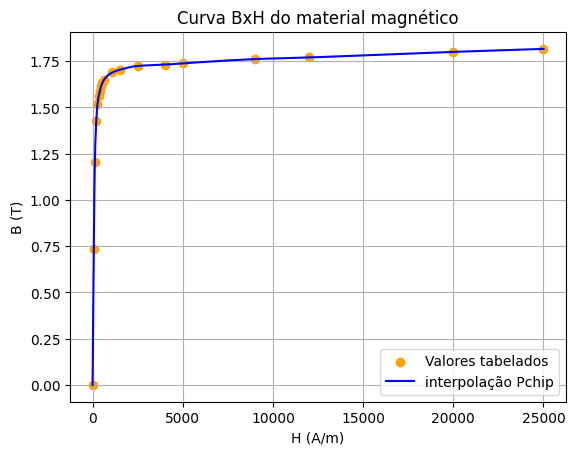

In [156]:
B_de_H = PchipInterpolator(H_tab, B_tab)

H_de_B = PchipInterpolator(B_tab, H_tab)

H_plot = np.linspace(H_tab[0], H_tab[-1], 1001)
B_plot = B_de_H(H_plot)

plt.scatter(H_tab, B_tab, label = 'Valores tabelados', color = 'orange')
plt.plot(H_plot, B_plot, label = 'interpolação Pchip', color = 'blue')
plt.grid(True)
plt.title('Curva BxH do material magnético')
plt.legend(loc = 'best')
plt.xlabel('H (A/m)')
plt.ylabel('B (T)')
plt.show()

## Etapa 1 ##

### Questão 1 ###

In [157]:
A_rotor = np.pi*alpha/180 * R * D
#A_nucleo = A_rotor

def alpha_sobreposicao(theta):
    '''
    Calcula o ângulo de sobreposição entre o rotor e o estador em função da posição angular do rotor.
    beta - theta, com beta = alpha
    '''
    if np.abs(theta) > 60:
        return np.abs(theta) - 60
    return alpha - np.abs(theta)

def Area_entreferro(theta):
    '''
    Calcula a área sobreposta entre o rotor e o estator em função da posição ângular do rotor.
    '''
    alpha_overleap = alpha_sobreposicao(theta)
    return np.pi*alpha_overleap/180 * R * D

def f_H_rotor(H_rotor, I, theta): 
    '''
    Função auxiliar para calcular o campo magnético no rotor.
    '''

    Ag = Area_entreferro(theta)

    queda_rotor = H_rotor * 2*R
    queda_entreferro = 2*np.max(B_de_H(H_rotor)) * A_rotor / (u0 * Ag) * g

    return queda_rotor + queda_entreferro - N*I

def determina_H_rotor(I, theta):
    '''
    Função que calcula o campo magnético no rotor para uma corrente e posição ângular dadas.
    '''
    
    def f_H_rotor_H(H_rotor):
        return f_H_rotor(H_rotor, I, theta)

    a = H_tab[0]
    b = H_de_B(1.9)

    for k in range(0, 21, 1): # Melhorar o método depois (falsa secante não deu certo)
        c = (a+b)/2
        
        fb = f_H_rotor_H(b)
        fc = f_H_rotor_H(c)

        if fb * fc < 0:
            a = c
        else:
            b = c
        
    return c

def determina_B_rotor(I, theta):
    '''
    Função que determina a densidade de fluxo magnético no rotor para uma corrente e posição ângular dadas.
    '''
    return B_de_H(determina_H_rotor(I, theta))

def Phi_B(I, theta):
    '''
    Função que calcula o fluxo magnético para uma corrente e posição ângular dadas;
    '''

    #if (I == 0) or (np.abs(theta) == 60):
    #    return 0

    B = determina_B_rotor(I, theta)
    return B*A_rotor

def fluxo_concatenado(I, theta):
    '''
    Função que calcula o fluxo concatenado para uma corrente e posição ângular dadas.
    '''
    return N*Phi_B(I, theta)


C:\Users\LucasGabriel\AppData\Local\Temp\ipykernel_3076\1827091453.py:28: RuntimeWarning: divide by zero encountered in scalar divide
  queda_entreferro = 2*np.max(B_de_H(H_rotor)) * A_rotor / (u0 * Ag) * g


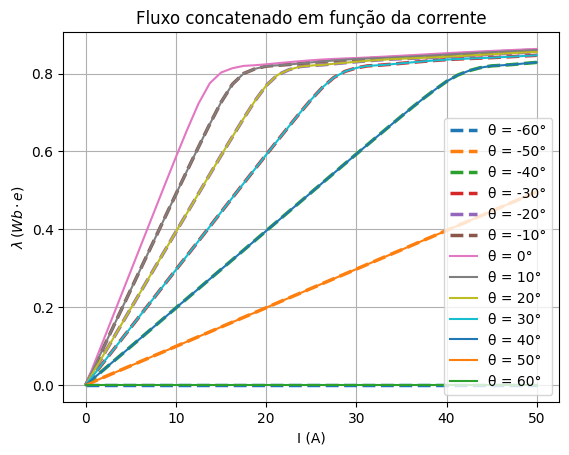

In [158]:
correntes = np.linspace(0,50,41)
angulos = np.arange(-60, 61, 10)

for angulo in angulos:
    fluxo_concatenado_array = np.array([fluxo_concatenado(I, angulo) for I in correntes])

    if angulo < 0:
        plt.plot(correntes, fluxo_concatenado_array, label = f'θ = {angulo}°', linestyle = '--', linewidth = 2.5)
    else:
        plt.plot(correntes, fluxo_concatenado_array, label = f'θ = {angulo}°')
plt.grid(True)
plt.legend(loc = 'lower right')
plt.xlabel('I (A)')
plt.ylabel(r'$\lambda\,(Wb\cdot e)$')
plt.title('Fluxo concatenado em função da corrente')
plt.show()

### Questão 2 ###

In [159]:
def f_I(B_rotor, I, theta): 
    '''
    Função auxiliar para calcular a corrempe para uma determinada densidade de fluxo magnético
    '''

    Ag = Area_entreferro(theta)

    queda_rotor = H_de_B(B_rotor) * 2*R
    queda_entreferro = 2*np.max(B_rotor) * A_rotor / (u0 * Ag) * g

    return queda_rotor + queda_entreferro - N*I

def determina_I_para_B(B_rotor, theta):
    
    def f_I_de_B(I):
        return f_I(B_rotor, I, theta)
    
    a = 0
    b = 200

    for k in range(0, 21, 1): # Melhorar o método depois (falsa secante não deu certo)
        c = (a+b)/2
        
        fb = f_I_de_B(b)
        fc = f_I_de_B(c)

        if fb * fc < 0:
            a = c
        else:
            b = c
        
    return c

In [160]:
B = 1.81 #T
theta = 0

I = determina_I_para_B(B, theta)

print('Para uma densidade de fluxo magnético de %.2f com \u03B8 = %d, deve-se ter I = %.2f A' %(B, theta, I))

Para uma densidade de fluxo magnético de 1.81 com θ = 0, deve-se ter I = 46.68 A


### Questão 3 ###

In [161]:
V = 2*Rb * I

print('A tensão a ser aplicada para gerar uma corrente de %.2f A é de %.2f V' %(I, V))

A tensão a ser aplicada para gerar uma corrente de 46.68 A é de 18.67 V


### Questão 4 ###